# Día 2: Clasificación de imágenes patológicas usando redes neuronales convolucionales con PyTorch

Antes de empezar, vamos a instalar algunas librerías que necesitaremos después:

```bash
# Primero, activa el entorno conda que creamos en la sesión anterior
conda activate ads
```

Después, instala `pytorch`. Las instrucciones de instalación dependiendo de tu sistema operativo, entorno, etc. se pueden consultar [aquí](https://pytorch.org/get-started/locally/).

Por último, instala el resto de librerías:

```bash
pip install medmnist --no-deps
pip install numpy pandas scikit-learn Pillow fire scikit-image
pip install pytorch-lightning torchmetrics torchsummary lovely-tensors captum
```

## Ecosistema de PyTorch

Usaremos el ecosistema de PyTorch para esta sesión de laboratorio. En particular, utilizaremos las siguientes librerías:

- `torch`: la librería principal, que proporciona las funcionalidades básicas para deep learning.
- `torchvision`: una librería que contiene datasets, arquitecturas de modelos y otras utilidades para visión por computador.
- `torchsummary`: una librería que proporciona un resumen de la arquitectura del modelo.
- `pytorch-lightning`: una librería que proporciona una interfaz de alto nivel para PyTorch, haciendo más fácil entrenar y evaluar modelos.
- `torchmetrics`: una librería que proporciona un conjunto de métricas para evaluar el rendimiento de los modelos.
- `lovely-tensors`: una librería que muestra tensores de una forma más legible al imprimirlos, lo que ayuda a entender mejor los datos y el modelo.

In [3]:
from tqdm import tqdm
import numpy as np
from pprint import pprint
from IPython.display import Image
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

import torch
import torchvision.transforms as transforms
import torch.nn as nn

import medmnist
from medmnist import INFO, Evaluator

# Esto sobreescribe la representación por defecto de los tensores para hacerla más legible
import lovely_tensors as lt
lt.monkey_patch()

## Conjunto de datos PathMNIST

PathMNIST es un dataset de imagen médica derivado de un estudio sobre cáncer colorrectal centrado en predecir la supervivencia de pacientes a partir de imágenes histológicas. El dataset consiste en 100.000 parches no solapados (NCT-CRC-HE-100K) extraídos de preparaciones histológicas teñidas con hematoxilina y eosina (H&E), junto con un conjunto de test separado de 7.180 imágenes (CRC-VAL-HE-7K) recogidas en un centro clínico distinto.

Las imágenes representan nueve tipos distintos de tejido relevantes para el análisis del cáncer colorrectal:
- Tejido adiposo
- Fondo (zonas sin tejido)
- Restos celulares
- Linfocitos (células inmunitarias que indican inflamación)
- Moco
- Tejido muscular liso
- Mucosa normal de colon
- Estroma asociado al cáncer
- Epitelio de adenocarcinoma colorrectal

Para facilitar el procesamiento, las imágenes originales en color de 3 canales y tamaño 224×224 píxeles se redimensionan a 28×28 píxeles manteniendo los canales RGB. El dataset principal se divide en entrenamiento (90%) y validación (10%), mientras que el conjunto CRC-VAL-HE-7K se usa como test. Esta estructura, y en particular el uso de datos de otro centro clínico para test, ayuda a comprobar si los modelos entrenados generalizan bien a distintos entornos médicos.

### Hiperparámetros

Aquí fijamos los hiperparámetros de datos y entrenamiento. Solo recuerda que están aquí, porque seguramente querrás cambiarlos más adelante.

In [4]:
# Hiperparámetros de datos
SIZE = 28 #64, 128, 224
DATA_FLAG = 'pathmnist'  # Dataset médico de imágenes patológicas
# DATA_FLAG = 'breastmnist'

# Hiperparámetros de entrenamiento
LEARNING_RATE = 0.001
NUM_EPOCHS = 2
BATCH_SIZE = 128

### Explorar los metadatos del conjunto de datos

In [5]:
# Obtener información del conjunto de datos
info = INFO[DATA_FLAG]
task = 'MULTICLASS' #info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

pprint(info)

{'MD5': 'a8b06965200029087d5bd730944a56c1',
 'MD5_128': 'ac42d08fb904d92c244187169d1fd1d9',
 'MD5_224': '2c51a510bcdc9cf8ddb2af93af1eadec',
 'MD5_64': '55aa9c1e0525abe5a6b9d8343a507616',
 'description': 'The PathMNIST is based on a prior study for predicting '
                'survival from colorectal cancer histology slides, providing a '
                'dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image '
                'patches from hematoxylin & eosin stained histological images, '
                'and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches '
                'from a different clinical center. The dataset is comprised of '
                '9 types of tissues, resulting in a multi-class classification '
                'task. We resize the source images of 3×224×224 into 3×28×28, '
                'and split NCT-CRC-HE-100K into training and validation set '
                'with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test '
                'set.

### Visualizar algunas muestras

In [6]:
info['python_class']

'PathMNIST'

100%|██████████| 206M/206M [02:46<00:00, 1.24MB/s]   


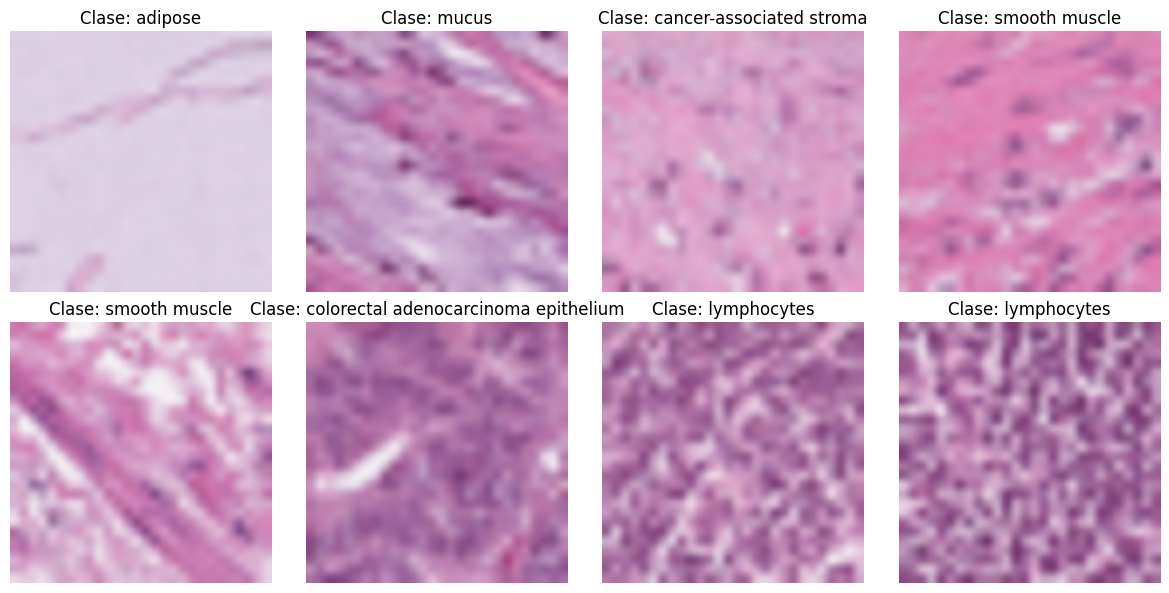

In [7]:
# Obtener la clase adecuada del conjunto de datos
DataClass = getattr(medmnist, info['python_class'])

# Visualizar algunas muestras
# Cargamos una versión sin transformaciones para visualizar
vis_dataset = DataClass(split='train', size=SIZE, download=True)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for idx in range(8):
    img, label = vis_dataset[idx]
    img = img.resize((224, 224))  # Reescalar desde 28x28
    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(f'Clase: {info["label"][str(label[0])]}' )

plt.tight_layout()
plt.show()

### Cargar el conjunto de datos y crear `dataloaders` de PyTorch

Dataset PathMNIST of size 28 (pathmnist)
    Number of datapoints: 89996
    Root location: /home/manel31/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
    Number of samples: {'train': 89996, 'val': 10004, 'test': 7180}
    Description: The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC

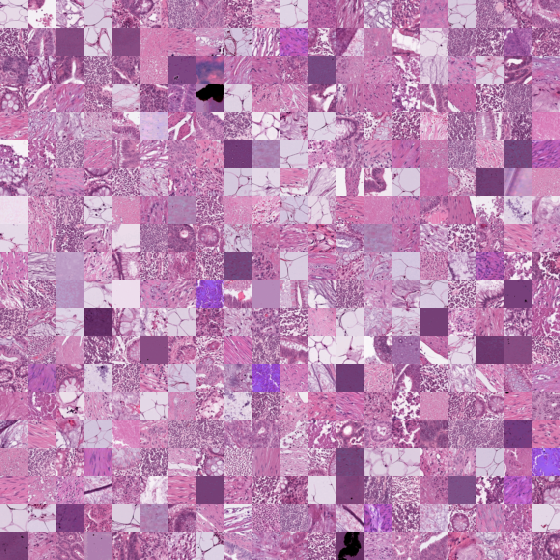

In [8]:
# Aumentos de datos
train_transform = transforms.Compose([
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomVerticalFlip(),
    # transforms.RandomRotation(20),
    # transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# Para validación y test solo necesitamos convertir a tensor y normalizar
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# Cargar datasets
train_dataset = DataClass(split='train', transform=train_transform, download=True)
val_dataset = DataClass(split='val', transform=eval_transform, download=True)
test_dataset = DataClass(split='test', transform=eval_transform, download=True)


# Crear dataloaders
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    shuffle=True
)
val_loader = torch.utils.data.DataLoader(
    dataset=val_dataset,
    batch_size=2*BATCH_SIZE,
    num_workers=0,
    shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=2*BATCH_SIZE,
    num_workers=0,
    shuffle=False
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

# Visualizar más muestras
# Para visualizar necesitamos un dataset sin normalización
vis_train_dataset = DataClass(split='train', transform=transforms.ToTensor(), download=True)
vis_train_dataset.montage(length=20)

In [9]:
# Gracias a lovely-tensors, los tensores de PyTorch se imprimen de una forma mucho más legible
# y eso facilita bastante la depuración de código en PyTorch
print(train_dataset[0])

(tensor[3, 28, 28] n=2352 (9.19 KiB) x∈[0.286 |▁▁▁▁▁▁▆▃▆█| 0.788] μ=0.696 σ=0.083, array([0]))


### Definir un modelo CNN sencillo

In [10]:
# Este es nuestro modelo base
class SmallestCNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(SmallestCNN, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU())

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.layer3 = nn.Sequential(
            nn.Conv2d(16, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.fc = nn.Sequential(
            nn.Linear(64 * 3 * 3, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Instanciar el modelo
model = SmallestCNN(in_channels=n_channels, num_classes=n_classes)

# Mostrar el modelo
print(model)

# Visualizar la red
from torchsummary import summary

sample_input = torch.randn(1, n_channels, 28, 28)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)  # Mover el modelo a GPU si está disponible
summary(model, input_size=(n_channels, 28, 28), device=device)

SmallestCNN(
  (layer1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer4): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kerne

### Entrenar el modelo

In [11]:
import pytorch_lightning as pl
import torch.optim as optim
from torchmetrics import AUROC, Accuracy
from pytorch_lightning.callbacks import TQDMProgressBar
from pytorch_lightning.loggers import CSVLogger

class LightningModel(pl.LightningModule):
    def __init__(self, base_model, num_classes, task, learning_rate=0.01):
        super().__init__()

        # Guardar el modelo base y la configuración
        self.model = base_model
        self.task = task
        self.learning_rate = learning_rate

        # Definir la función de pérdida según la tarea
        if self.task == 'binary':
            self.loss_fn = nn.BCEWithLogitsLoss()
        else:
            self.loss_fn = nn.CrossEntropyLoss()

        # Añadir métricas de validación; para binario no debe indicarse num_classes
        metric_kwargs = {'task': self.task}
        if self.task != 'binary':
            metric_kwargs['num_classes'] = num_classes

        self.val_auroc = AUROC(**metric_kwargs)
        self.val_accuracy = Accuracy(**metric_kwargs)

        # Añadir métricas de test
        self.test_auroc = AUROC(**metric_kwargs)
        self.test_accuracy = Accuracy(**metric_kwargs)

        # Para almacenar resultados de test
        self.test_preds = []
        self.test_targets = []

    def forward(self, x):
        # Definir el forward
        return self.model(x)

    def configure_optimizers(self):
        # Definir el optimizador (equivalente a la configuración original con SGD)
        return optim.SGD(self.parameters(), lr=self.learning_rate, momentum=0.9)

    def _shared_step(self, batch, batch_idx):
        # Operaciones comunes para entrenamiento, validación y test
        inputs, targets = batch
        outputs = self.forward(inputs)

        if self.task == 'binary':
            outputs = outputs.squeeze()
            targets = targets.squeeze().float()
            loss = self.loss_fn(outputs, targets)
            probs = torch.sigmoid(outputs)
        else: # multiclase
            targets = targets.squeeze().long()
            loss = self.loss_fn(outputs, targets)
            probs = outputs.softmax(dim=-1)

        return loss, probs, targets

    def training_step(self, batch, batch_idx):
        loss, probs, targets = self._shared_step(batch, batch_idx)
        # Añadir métricas a la barra de progreso
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, probs, targets = self._shared_step(batch, batch_idx)

        # En tarea binaria, las métricas esperan targets enteros
        metric_targets = targets.long()

        self.val_auroc.update(probs, metric_targets)
        self.val_accuracy.update(probs, metric_targets)
        # Añadir métricas a la barra de progreso
        self.log('val_loss', loss, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        # Calcular y registrar métricas al final de cada época
        auc = self.val_auroc.compute()
        acc = self.val_accuracy.compute()
        self.log('val_auc', auc)
        self.log('val_acc', acc, prog_bar=True)
        self.val_auroc.reset()
        self.val_accuracy.reset()

    def on_test_start(self):
        # Vaciar listas de predicciones y targets al empezar el test
        self.test_preds.clear()
        self.test_targets.clear()

    def test_step(self, batch, batch_idx):
        loss, probs, targets = self._shared_step(batch, batch_idx)

        # En tarea binaria, las métricas esperan targets enteros
        metric_targets = targets.long()

        # Actualizar métricas de test
        self.test_auroc.update(probs, metric_targets)
        self.test_accuracy.update(probs, metric_targets)
        self.log('test_loss', loss, prog_bar=True)

        # Guardar predicciones y targets
        self.test_preds.append(probs)
        self.test_targets.append(targets)

        return loss

    def on_test_epoch_end(self):
        # Calcular y registrar métricas al final del test
        test_auc = self.test_auroc.compute()
        test_acc = self.test_accuracy.compute()
        self.log('test_auc', test_auc)
        self.log('test_acc', test_acc, prog_bar=True)
        self.test_auroc.reset()
        self.test_accuracy.reset()

# Configurar entrenamiento
model = SmallestCNN(in_channels=n_channels, num_classes=n_classes)
lightning_model = LightningModel(
    model,
    num_classes=n_classes,
    task=task,
    learning_rate=LEARNING_RATE
)

# Crear logger
logger = CSVLogger(save_dir='lightning_logs', name="pathmnist_smallcnn", version=1)

# Crear trainer
trainer = pl.Trainer(
    max_epochs=NUM_EPOCHS,
    accelerator='auto',  # Detectar automáticamente GPU o CPU
    enable_progress_bar=True,  # Activar barra de progreso
    callbacks=[TQDMProgressBar(refresh_rate=1, leave=True)],
    logger=logger
)

# Obtener una puntuación inicial de validación
trainer.validate(
    model=lightning_model,
    dataloaders=val_loader
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/manel31/miniconda3/envs/curso_ia/lib/python3.12/site-packages/

Validation DataLoader 0: 100%|██████████| 40/40 [00:01<00:00, 34.62it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_acc            0.13534586131572723
         val_auc            0.5562705397605896
        val_loss             2.195899248123169
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'val_loss': 2.195899248123169,
  'val_auc': 0.5562705397605896,
  'val_acc': 0.13534586131572723}]

In [12]:
# Entrenar
trainer.fit(
    model=lightning_model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

# Guardar el módulo Lightning completo
trainer.save_checkpoint("weights_smallcnn.ckpt")

# Evaluar en el conjunto de test
print("Evaluando en el conjunto de test...")
smallcnn_results = trainer.test(lightning_model, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type               | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | model         | SmallestCNN        | 127 K  | train | 0    
1 | loss_fn       | CrossEntropyLoss   | 0      | train | 0    
2 | val_auroc     | MulticlassAUROC    | 0      | train | 0    
3 | val_accuracy  | MulticlassAccuracy | 0      | train | 0    
4 | test_auroc    | MulticlassAUROC    | 0      | train | 0    
5 | test_accuracy | MulticlassAccuracy | 0      | train | 0    
---------------------------------------------------------------------
127 K     Trainable params
0         Non-trainable params
127 K     Total params
0.510     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode
0         Total Flops


/home/manel31/miniconda3/envs/curso_ia/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 704/704 [00:14<00:00, 49.27it/s, v_num=1, train_loss=1.600, val_loss=1.010, val_acc=0.643]


`Trainer.fit` stopped: `max_epochs=2` reached.
`weights_only` was not set, defaulting to `False`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/manel31/miniconda3/envs/curso_ia/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Evaluando en el conjunto de test...
Testing DataLoader 0: 100%|██████████| 29/29 [00:00<00:00, 38.44it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc             0.548328697681427
        test_auc            0.9234699606895447
        test_loss           1.8053264617919922
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


### Visualizar los logs de entrenamiento

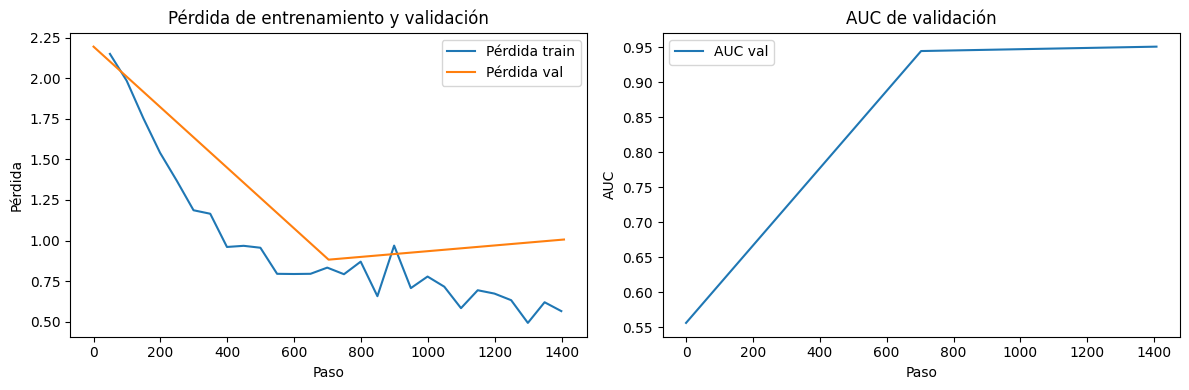

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_loss(csv_path):
    # Leer el archivo CSV
    metrics_df = pd.read_csv(csv_path)

    # Crear las gráficas
    plt.figure(figsize=(12, 4))

    # Gráfica de pérdida
    plt.subplot(1, 2, 1)
    sns.lineplot(metrics_df.loc[~metrics_df['train_loss'].isna(), ['step', 'train_loss']], 
                x='step', y='train_loss', label='Pérdida train')
    sns.lineplot(metrics_df.loc[~metrics_df['val_loss'].isna(), ['step', 'val_loss']], 
                x='step', y='val_loss', label='Pérdida val')
    plt.xlabel('Paso')
    plt.ylabel('Pérdida')
    plt.title('Pérdida de entrenamiento y validación')
    plt.legend()

    # Gráfica de AUC
    plt.subplot(1, 2, 2)
    sns.lineplot(metrics_df.loc[~metrics_df['val_auc'].isna(), ['step', 'val_auc']], 
                x='step', y='val_auc', label='AUC val')
    plt.xlabel('Paso')
    plt.ylabel('AUC')
    plt.title('AUC de validación')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_loss(f"{logger.log_dir}/metrics.csv")

## Evaluación más profunda del modelo

Ahora que ya tenemos un modelo entrenado, podemos evaluarlo con más detalle en lugar de quedarnos solo con la accuracy y el AUC. Nos centraremos en la interpretabilidad de los resultados desde una perspectiva médica.

### Matriz de confusión

Una matriz de confusión nos da un desglose detallado de cómo se alinean las predicciones del modelo con las etiquetas reales. Cada fila de la matriz representa las instancias de una clase real y cada columna representa las instancias predichas en una clase. Es una herramienta muy útil para ver qué clases está confundiendo el modelo.

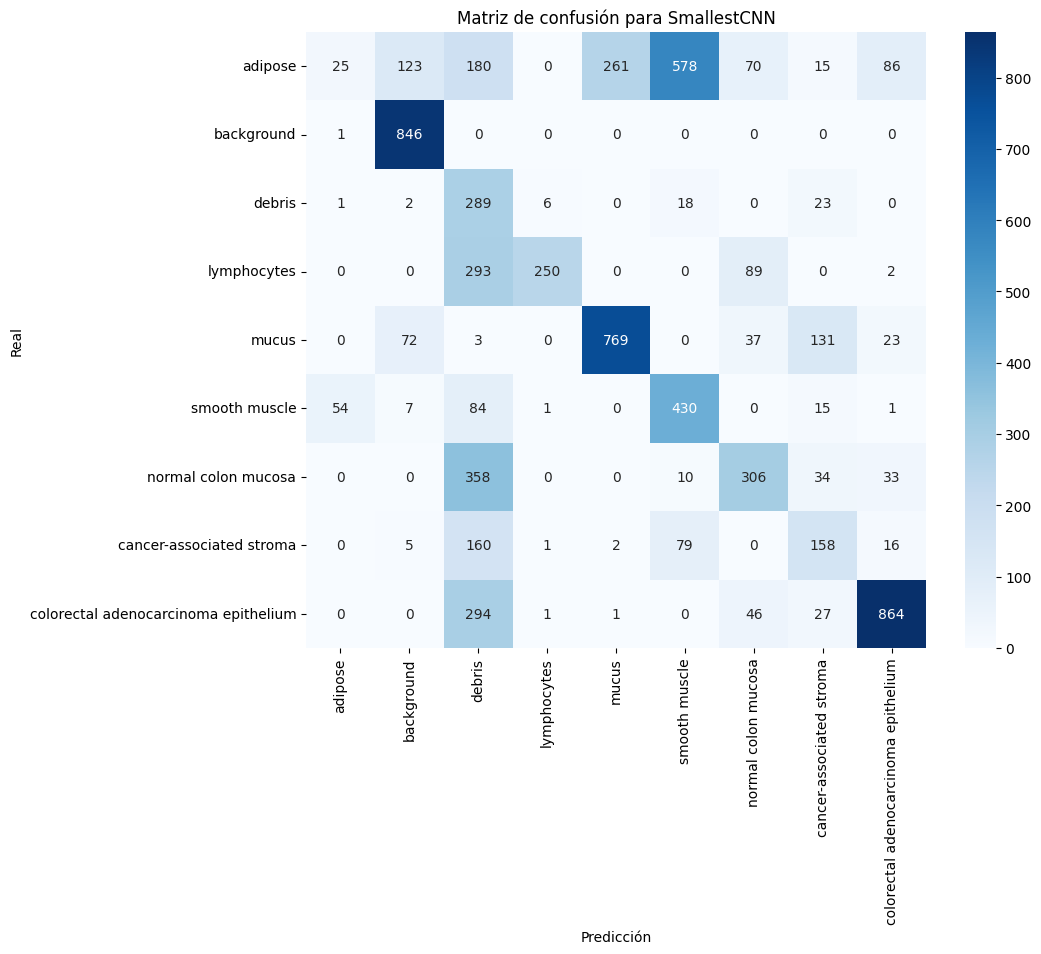

In [14]:
# Obtener predicciones y etiquetas del modelo
all_preds = torch.cat(lightning_model.test_preds).cpu().numpy()
all_targets = torch.cat(lightning_model.test_targets).cpu().numpy()

# Obtener la clase predicha con mayor probabilidad
pred_labels = np.argmax(all_preds, axis=1)

# Calcular la matriz de confusión
cm = confusion_matrix(all_targets, pred_labels)

# Representar la matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=info['label'].values(), 
            yticklabels=info['label'].values())
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión para SmallestCNN')
plt.show()

### Análisis de una clase concreta: adenocarcinoma

En contexto médico, a menudo nos interesa especialmente el rendimiento del modelo para una patología concreta. En este caso, la clase más crítica es `'colorectal adenocarcinoma epithelium'`. Vamos a analizar específicamente el comportamiento del modelo al detectar este tipo de cáncer.

Podemos simplificar el problema a una tarea de clasificación binaria: **adenocarcinoma frente a no adenocarcinoma**. Esto nos permite calcular métricas muy habituales en diagnóstico médico:

- **Sensibilidad (o recall o tasa de verdaderos positivos)**: ¿qué tal detecta el modelo la patología cuando realmente está presente? `TP / (TP + FN)`
- **Especificidad (o tasa de verdaderos negativos)**: ¿qué tal identifica el modelo correctamente un caso como negativo cuando la patología no está presente? `TN / (TN + FP)`
- **Valor predictivo positivo (VPP o precisión)**: cuando el modelo predice un caso positivo, ¿con qué probabilidad acierta? `TP / (TP + FP)`

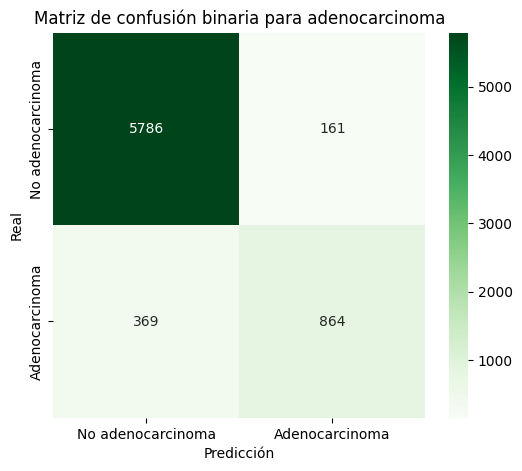

Informe de clasificación para adenocarcinoma frente al resto:
                   precision    recall  f1-score   support

No adenocarcinoma       0.94      0.97      0.96      5947
   Adenocarcinoma       0.84      0.70      0.77      1233

         accuracy                           0.93      7180
        macro avg       0.89      0.84      0.86      7180
     weighted avg       0.92      0.93      0.92      7180



In [15]:
from sklearn.metrics import classification_report

# Definir la clase de interés
adenocarcinoma_class_id = 8 # 'colorectal adenocarcinoma epithelium'

# Crear etiquetas binarias
binary_targets = (all_targets == adenocarcinoma_class_id).astype(int)
binary_preds = (pred_labels == adenocarcinoma_class_id).astype(int)

# Calcular la matriz de confusión binaria
binary_cm = confusion_matrix(binary_targets, binary_preds)

# Representar la matriz de confusión binaria
plt.figure(figsize=(6, 5))
sns.heatmap(binary_cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No adenocarcinoma', 'Adenocarcinoma'], 
            yticklabels=['No adenocarcinoma', 'Adenocarcinoma'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión binaria para adenocarcinoma')
plt.show()

print("Informe de clasificación para adenocarcinoma frente al resto:")
report = classification_report(binary_targets, binary_preds,
                               target_names=['No adenocarcinoma', 'Adenocarcinoma'])
print(report)

## Uso de un modelo más avanzado: MobileNetV3

Ahora vamos a explorar una arquitectura más compleja y potente, `MobileNetV3`. Este modelo forma parte de una familia de arquitecturas eficientes diseñadas para dispositivos móviles, pero también muy eficaces en muchas tareas de visión por computador. Ha sido preentrenado sobre el gran dataset ImageNet, por lo que ya ha aprendido una gran cantidad de características útiles a partir de imágenes naturales. Usaremos la versión pequeña, `MobileNetV3 small`.

Usar un modelo preentrenado es una técnica muy habitual en deep learning llamada **transfer learning**. La idea es reutilizar el conocimiento aprendido en un dataset grande y aplicarlo a nuestro propio problema, que normalmente dispone de menos datos. Solo necesitamos sustituir la última capa de clasificación para ajustarla al número de clases de nuestra tarea.

Vamos a entrenar `MobileNetV3` y comparar su comportamiento con `SmallestCNN`.

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/manel31/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:13<00:00, 787kB/s] 
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type               | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | model         | MobileNetV3        | 1.5 M  | train | 0    
1 | loss_fn       | CrossEntropyLoss   | 0      | train | 0    
2 | val_auroc     | MulticlassAUROC    | 0      | train | 0    
3 | val_accuracy  | MulticlassAccuracy | 0      | train | 0    

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/manel31/miniconda3/envs/curso_ia/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/manel31/miniconda3/envs/curso_ia/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


/home/manel31/miniconda3/envs/curso_ia/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 704/704 [00:20<00:00, 33.64it/s, v_num=1, train_loss=0.769, val_loss=0.472, val_acc=0.832]


`Trainer.fit` stopped: `max_epochs=2` reached.
`weights_only` was not set, defaulting to `False`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Evaluando MobileNetV3 en el conjunto de test...


/home/manel31/miniconda3/envs/curso_ia/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 29/29 [00:00<00:00, 35.13it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.7654595971107483
        test_auc            0.9630662202835083
        test_loss           0.6721422076225281
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


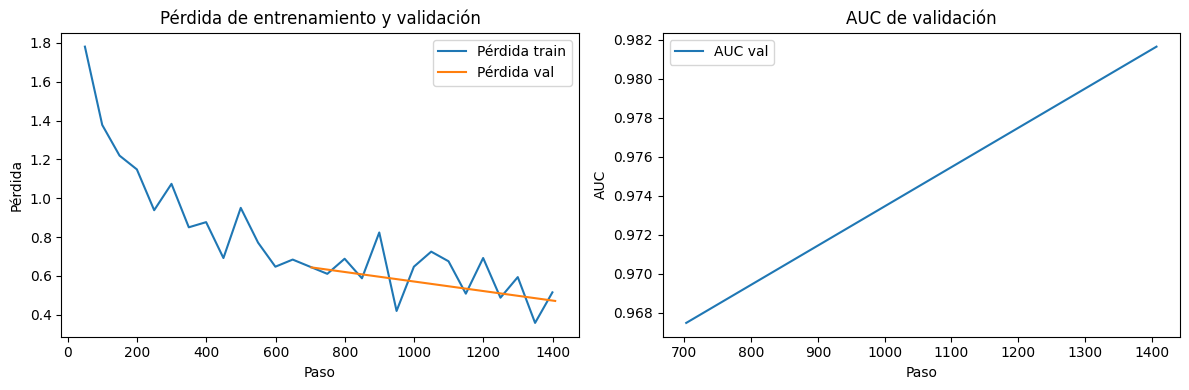

In [16]:
from torchvision.models import mobilenet_v3_small

# Cargar MobileNetV3 small preentrenado
mobilenet_model = mobilenet_v3_small(weights='IMAGENET1K_V1')

# Adaptar la capa final al número de clases de nuestro problema
num_ftrs = mobilenet_model.classifier[-1].in_features
mobilenet_model.classifier[-1] = nn.Linear(num_ftrs, n_classes)

# Crear un nuevo LightningModel para MobileNetV3
lightning_mobilenet = LightningModel(
    mobilenet_model,
    num_classes=n_classes,
    task=task,
    learning_rate=LEARNING_RATE
)

# Crear un logger nuevo para este modelo
mobilenet_logger = CSVLogger(save_dir='lightning_logs', name="pathmnist_mobilenetv3", version=1)

# Crear un nuevo trainer
mobilenet_trainer = pl.Trainer(
    max_epochs=NUM_EPOCHS,
    accelerator='auto',
    enable_progress_bar=True,
    callbacks=[TQDMProgressBar(refresh_rate=1, leave=True)],
    logger=mobilenet_logger
)

# Entrenar el modelo
mobilenet_trainer.fit(
    model=lightning_mobilenet,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

# Guardar el checkpoint
mobilenet_trainer.save_checkpoint("weights_mobilenetv3.ckpt")

# Evaluar en test
print("Evaluando MobileNetV3 en el conjunto de test...")
mobilenet_results = mobilenet_trainer.test(lightning_mobilenet, test_loader)

# Representar las curvas de entrenamiento
plot_loss(f"{mobilenet_logger.log_dir}/metrics.csv")

## IA explicable (XAI) con Grad-CAM

Los modelos de deep learning suelen considerarse "cajas negras" porque cuesta entender cómo llegan a una decisión concreta. Las técnicas de **IA explicable (XAI)** intentan arrojar luz sobre ese proceso.

Una técnica muy popular en visión es **Grad-CAM (*Gradient-weighted Class Activation Mapping*)**. Grad-CAM produce un mapa de localización aproximado que resalta las regiones importantes de la imagen para predecir una clase concreta. En contexto médico, esto puede ser muy valioso para comprobar que el modelo está "mirando" las regiones correctas del tejido y no artefactos irrelevantes.

Usaremos la librería [Captum](https://captum.ai/), construida sobre PyTorch, para aplicar Grad-CAM a nuestro `SmallestCNN`. Analizaremos en qué se fija el modelo para varios ejemplos del conjunto de test.

/home/manel31/miniconda3/envs/curso_ia/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


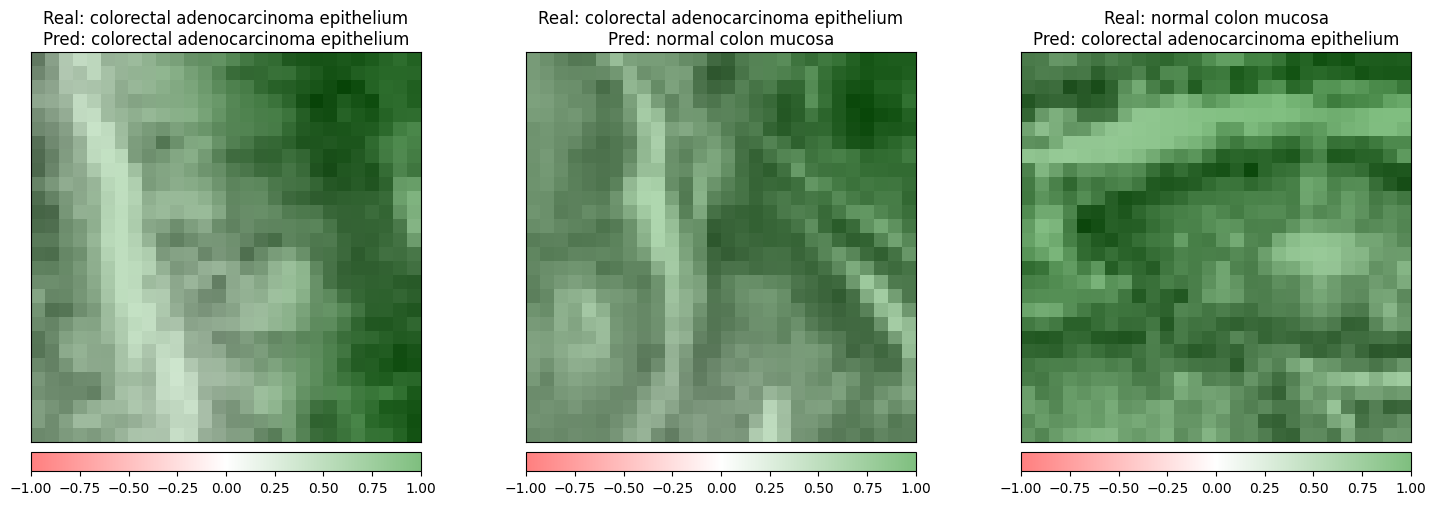

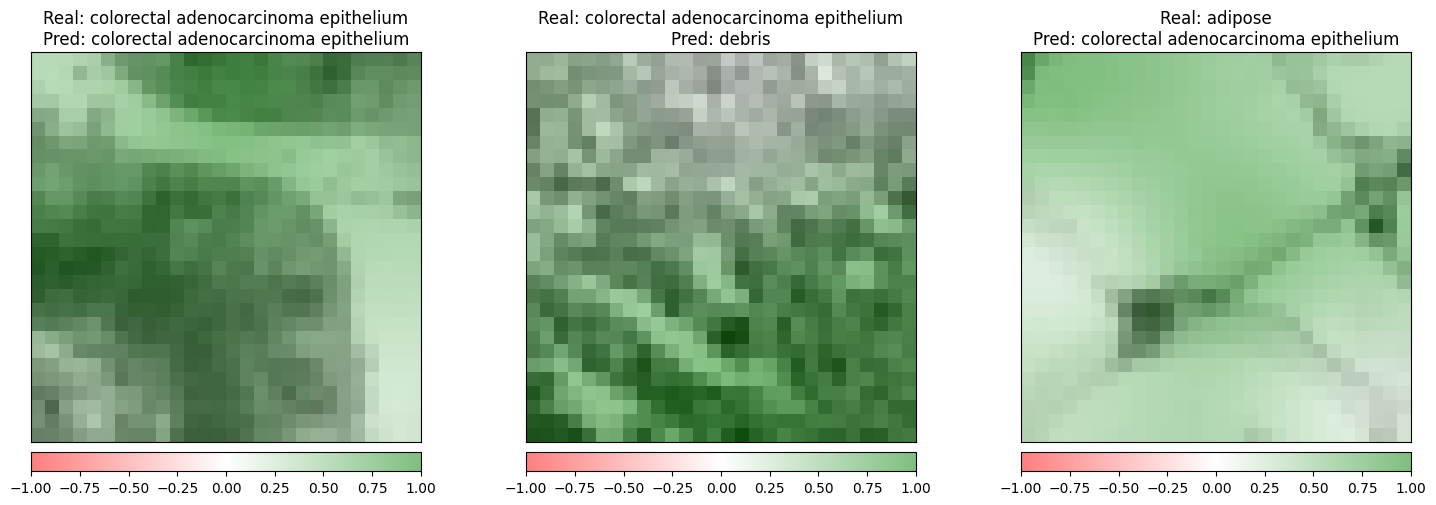

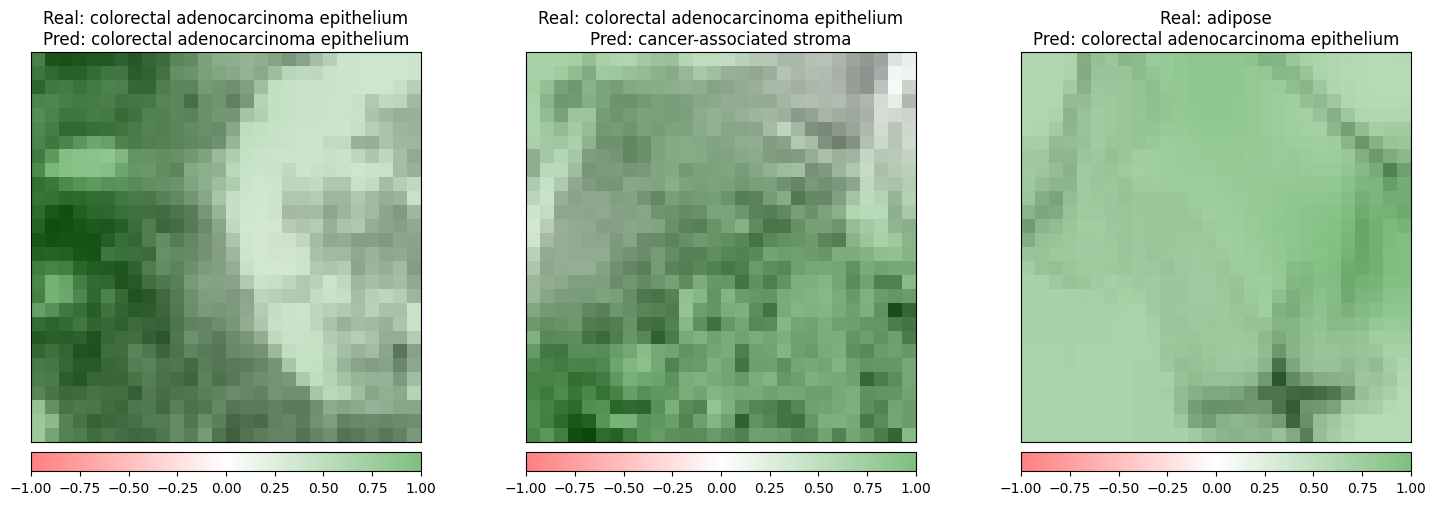

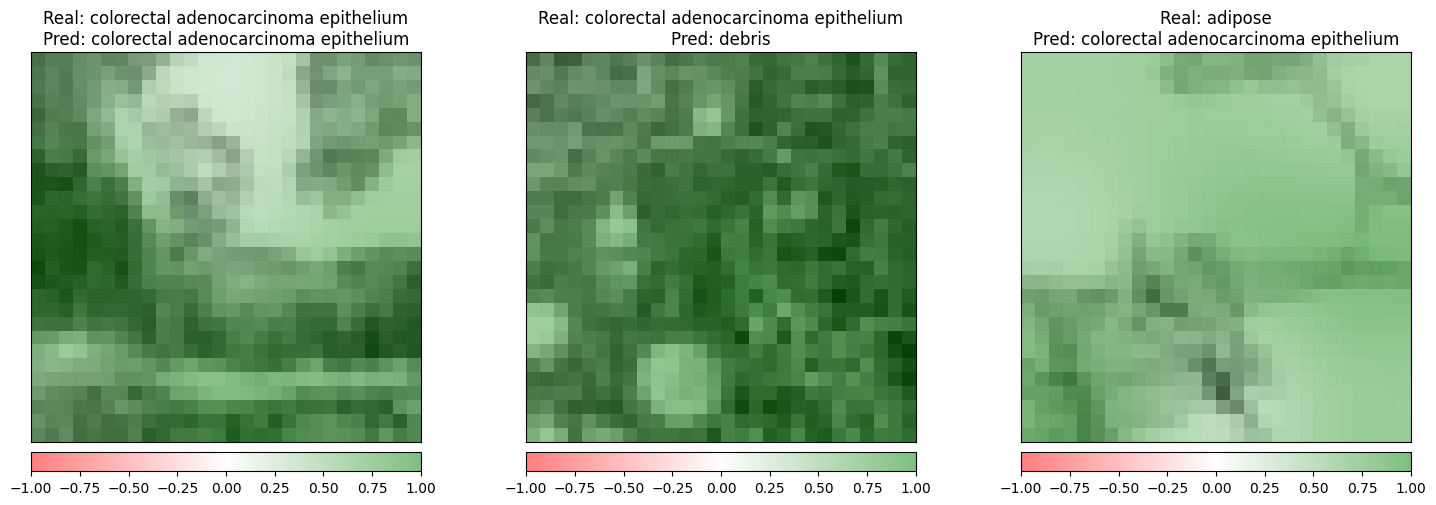

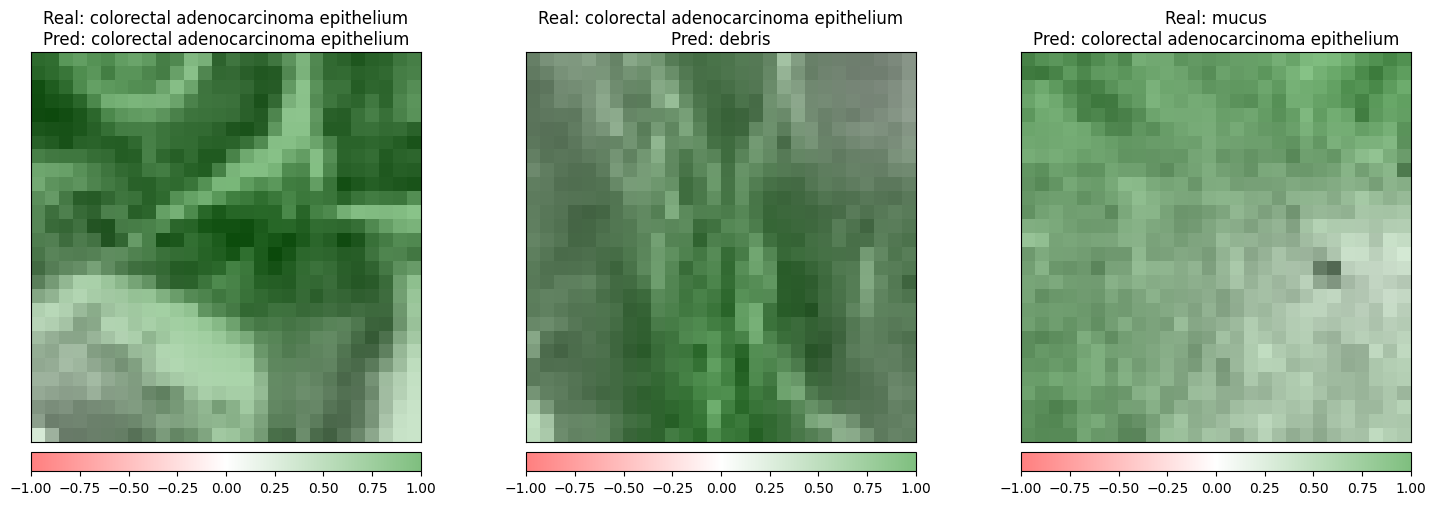

In [17]:
# Importaciones para Captum
from captum.attr import LayerGradCam
from captum.attr import visualization as viz
from captum.attr import LayerAttribution

# Poner el modelo en modo evaluación
small_cnn_model = lightning_model.model.to(device)
small_cnn_model.eval()

# Inicializar Grad-CAM con la capa objetivo
layer_gc = LayerGradCam(small_cnn_model, small_cnn_model.layer4)

# Función auxiliar para desnormalizar la imagen al visualizarla
def denormalize(tensor):
    tensor = tensor.clone()
    mean = torch.tensor([0.5, 0.5, 0.5], device=tensor.device)
    std = torch.tensor([0.5, 0.5, 0.5], device=tensor.device)
    tensor.mul_(std[:, None, None]).add_(mean[:, None, None])
    return tensor

# Buscar imágenes interesantes del conjunto de test
smallcnn_preds = torch.cat(lightning_model.test_preds)
smallcnn_pred_labels = torch.argmax(smallcnn_preds, axis=1)
smallcnn_targets = torch.cat(lightning_model.test_targets)

correct_adeno_indices = torch.where((smallcnn_targets == 8) & (smallcnn_pred_labels == 8))[0]
misclassified_adeno_indices = torch.where((smallcnn_targets == 8) & (smallcnn_pred_labels != 8))[0]
false_positive_adeno_indices = torch.where((smallcnn_targets != 8) & (smallcnn_pred_labels == 8))[0]

for set_idx in range(5):
    indices_to_visualize = []
    if len(correct_adeno_indices) > set_idx:
        indices_to_visualize.append(correct_adeno_indices[set_idx])
    if len(misclassified_adeno_indices) > set_idx:
        indices_to_visualize.append(misclassified_adeno_indices[set_idx])
    if len(false_positive_adeno_indices) > set_idx:
        indices_to_visualize.append(false_positive_adeno_indices[set_idx])

    fig, axes = plt.subplots(1, len(indices_to_visualize), figsize=(15, 5))
    if len(indices_to_visualize) == 1:
        axes = [axes]

    for i, img_idx in enumerate(indices_to_visualize):
        input_tensor, true_label = test_dataset[img_idx]
        input_tensor = input_tensor.unsqueeze(0).to(device)

        pred_label = smallcnn_pred_labels[img_idx].to(device)

        attribution = layer_gc.attribute(input_tensor, target=pred_label)

        upsampled_attr = LayerAttribution.interpolate(attribution, (28, 28), interpolate_mode="bicubic")

        img_to_show = denormalize(input_tensor.squeeze()).cpu().permute(1, 2, 0).numpy()

        viz.visualize_image_attr(
            upsampled_attr[0].cpu().permute(1, 2, 0).detach().numpy(),
            img_to_show,
            method="blended_heat_map",
            sign="all",
            show_colorbar=True,
            title=f"Real: {info['label'][str(true_label[0])]}\nPred: {info['label'][str(pred_label.item())]}",
            plt_fig_axis=(fig, axes[i]),
            use_pyplot=False
        )

    plt.tight_layout()
    plt.show()